<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/second/Evaluacion_3_Rebeca_Alvarez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

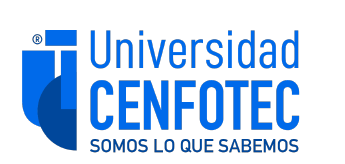

Estudiante: Rebeca Alvarez

Universidad CENFOTEC

Curso: Proyecto Integrador en IA

Nombre del Profesor a Cargo: Alexander Bermudez

Fecha: Mayo, 2026

#**Descripción del dataset original**

In [ ]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [ ]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# =========================
# 1. Cargar dataset
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DESCRIPCIÓN GENERAL DEL DATASET")
print("-" * 50)
print("Filas y columnas:", df.shape)
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

DESCRIPCIÓN GENERAL DEL DATASET
--------------------------------------------------
Filas y columnas: (28332, 24)
Cantidad de filas: 28332
Cantidad de columnas: 24

Columnas del dataset:
['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']

Primeras filas:


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doReco

##1. Resumen de tipos de variables

In [ ]:
# =========================
# 2. Tipos de variables
# =========================

tipos_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str),
    "Valores no nulos": df.notnull().sum().values,
    "Valores nulos": df.isnull().sum().values,
    "Porcentaje nulos": ((df.isnull().sum() / len(df)) * 100).round(2).values,
    "Valores únicos": df.nunique(dropna=False).values
})

display(tipos_variables)

,Variable,Tipo de dato,Valores no nulos,Valores nulos,Porcentaje nulos,Valores únicos
id,id,object,28332,0,0.00,65
dateAdded,dateAdded,object,28332,0,0.00,55
dateUpdated,dateUpdated,object,28332,0,0.00,52
name,name,object,28332,0,0.00,65
asins,asins,object,28332,0,0.00,65
brand,brand,object,28332,0,0.00,3
categories,categories,object,28332,0,0.00,60
primaryCategories,primaryCategories,object,28332,0,0.00,9
imageURLs,imageURLs,object,28332,0,0.00,65
keys,keys,object,28332,0,0.00,65


##Análisis de variables altamente correlacionadas

(Los problemas de cardinalidad alta, desbalance de clases y escalas inconsistentes se tomaron del avance anterior, y se documentaron en el documento de word)



In [ ]:
import pandas as pd

df = pd.read_csv("Amazon_Consumer_Review.csv")

# =========================
# 3. Crear variables numéricas auxiliares
# =========================

df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Variables numéricas disponibles
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Variables numéricas detectadas:")
print(numeric_df.columns.tolist())

# =========================
# 4. Matriz de correlación
# =========================

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))

# =========================
# 5. Identificar correlaciones altas
# =========================

correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlación consigo misma
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Evitar duplicados
correlation_pairs["Par ordenado"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par ordenado")
correlation_pairs = correlation_pairs.drop(columns=["Par ordenado"])

# Filtrar correlaciones fuertes
high_correlations = correlation_pairs[
    correlation_pairs["Correlación"].abs() >= 0.70
].sort_values(by="Correlación", ascending=False)

print("Variables altamente correlacionadas:")
display(high_correlations.round(3))

Variables numéricas detectadas:
['reviews.id', 'reviews.numHelpful', 'reviews.rating', 'review_length_chars', 'review_length_words']


,reviews.id,reviews.numHelpful,reviews.rating,review_length_chars,review_length_words
reviews.id,1.000,-0.554,0.075,-0.009,-0.016
reviews.numHelpful,-0.554,1.000,-0.041,0.237,0.233
reviews.rating,0.075,-0.041,1.000,-0.120,-0.120
review_length_chars,-0.009,0.237,-0.120,1.000,0.997
review_length_words,-0.016,0.233,-0.120,0.997,1.000


Variables altamente correlacionadas:


,Variable 1,Variable 2,Correlación
19,review_length_chars,review_length_words,0.997


In [ ]:
#Vamos a modificar la columna reviews.username a que sea string, para que pueda ser parte de las correlaciones
# Reemplazar nulos y convertir a texto
df["reviews.username"] = df["reviews.username"].fillna("unknown").astype("string")

# Verificar resultado
print(df["reviews.username"].dtype)
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# Convertir reviews.username a tipo texto/string
df["reviews.username"] = df["reviews.username"].astype("string")

# Verificar el tipo de dato
print(df["reviews.username"].dtype)

# Ver primeras filas
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# =========================
# 6. Asociación entre variables de texto (Cramér's V + coincidencia + tablas cruzadas)
# =========================

from scipy.stats import chi2_contingency
import numpy as np
import itertools

text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")


def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)

print("Resumen de asociación entre variables categóricas:")
display(summary_df.sort_values("Cramér's V", ascending=False).round(4))

# Mostrar tablas cruzadas para revisar posibles réplicas
for r in results:
    print(f"\nTabla cruzada: {r['Variable 1']} vs {r['Variable 2']}")
    display(r["Tabla cruzada"])



Resumen de asociación entre variables categóricas:


,Variable 1,Variable 2,Cramér's V,% coincidencia
0,brand,manufacturer,0.7071,99.9188
1,brand,reviews.username,0.6524,0.0035
2,manufacturer,reviews.username,0.6129,0.0035



Tabla cruzada: brand vs manufacturer


manufacturer,Amazon,Amazon Digital Services,Amazon.com,AmazonBasics
brand,,,,
Amazon,16130,18,5,0
AmazonBasics,0,0,0,10
Amazonbasics,0,0,0,12169



Tabla cruzada: brand vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
brand,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazonbasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Tabla cruzada: manufacturer vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
manufacturer,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
Amazon Digital Services,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazon.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Interpretación de los resultados**

Estos resultados analizan la asociación entre variables categóricas usando Cramér’s V y porcentaje de coincidencia. En general, muestran que existe una relación fuerte entre brand y manufacturer, mientras que las asociaciones con reviews.username deben interpretarse con mucha cautela por su alta cardinalidad.

1. Asociación entre brand y manufacturer

| Variable 1 | Variable 2     | Cramér’s V | % coincidencia |
| ---------- | -------------- | ---------: | -------------: |
| `brand`    | `manufacturer` |     0.7071 |       99.9188% |


El valor de Cramér’s V = 0.7071 indica una asociación alta entre brand y manufacturer.

Además, el porcentaje de coincidencia es de 99.9188%, lo cual significa que ambas variables contienen prácticamente la misma información en casi todos los registros.

La tabla cruzada confirma esto:

| brand        | Amazon | Amazon Digital Services | Amazon.com | AmazonBasics |
| ------------ | -----: | ----------------------: | ---------: | -----------: |
| Amazon       |  16130 |                      18 |          5 |            0 |
| AmazonBasics |      0 |                       0 |          0 |           10 |
| Amazonbasics |      0 |                       0 |          0 |        12169 |


La mayoría de registros con brand = Amazon tienen manufacturer = Amazon. De igual forma, brand = Amazonbasics se asocia casi completamente con manufacturer = AmazonBasics.

Conclusión

brand y manufacturer son variables altamente redundantes.

Para el modelo, no es necesario usar ambas. Se recomienda conservar solo una para evitar duplicidad de información.

Para mi modelo, conservaré brand, porque es más clara desde el punto de vista de negocio y suele representar mejor la identidad comercial del producto.

También conviene normalizar valores como:

AmazonBasics
Amazonbasics

porque representan probablemente la misma marca, pero están escritos con diferente capitalización.

2. Asociación entre brand y reviews.username

| Variable 1 | Variable 2         | Cramér’s V | % coincidencia |
| ---------- | ------------------ | ---------: | -------------: |
| `brand`    | `reviews.username` |     0.6524 |        0.0035% |


A primera vista, Cramér’s V = 0.6524 parece indicar una asociación moderada-alta. Sin embargo, el porcentaje de coincidencia es prácticamente cero: 0.0035%.

Esto ocurre porque reviews.username tiene una cardinalidad extremadamente alta: la tabla muestra 16,269 columnas, una por cada usuario.

Cuando una variable categórica tiene muchísimos valores únicos, Cramér’s V puede dar una impresión inflada de asociación, especialmente si muchos usuarios aparecen pocas veces o solo asociados a una marca por casualidad.

En otras palabras, la asociación no necesariamente significa que el usuario explique la marca o que sea útil para el modelo. Puede ser un efecto estadístico causado por la alta cardinalidad.

Conclusión

reviews.username no debe considerarse una variable útil para el modelo.

Aunque Cramér’s V parece alto, la variable tiene demasiadas categorías, baja generalización y puede introducir ruido.

En mi modelo voy a excluir reviews.username del modelo predictivo.

Razones:

alta cardinalidad;
poco valor predictivo generalizable;
riesgo de sobreajuste;
posible problema de privacidad;
no aporta lógica de negocio directa para predecir caída en desempeño.

3. Asociación entre manufacturer y reviews.username

| Variable 1     | Variable 2         | Cramér’s V | % coincidencia |
| -------------- | ------------------ | ---------: | -------------: |
| `manufacturer` | `reviews.username` |     0.6129 |        0.0035% |


Interpretación

El caso es similar al anterior. El valor de Cramér’s V = 0.6129 puede parecer alto, pero está influenciado por la alta cardinalidad de reviews.username.

La tabla cruzada muestra muchísimos usuarios, y casi todos se concentran bajo manufacturer = Amazon, porque el dataset está dominado por productos de Amazon.

Esto no significa que reviews.username sea una buena variable predictiva. Significa más bien que muchos usuarios aparecen en un dataset donde casi todos los productos pertenecen a Amazon o AmazonBasics.

Conclusión

La asociación entre manufacturer y reviews.username no debe usarse como argumento para conservar reviews.username.

La relación es poco útil desde el punto de vista predictivo y puede generar sobreajuste.

4. Hallazgos principales

| Hallazgo                                              | Interpretación                       | Decisión recomendada               |
| ----------------------------------------------------- | ------------------------------------ | ---------------------------------- |
| `brand` y `manufacturer` están altamente asociados    | Contienen información casi duplicada | Conservar solo una                 |
| `brand` y `manufacturer` tienen 99.9% de coincidencia | Son variables redundantes            | Preferir `brand`                   |
| `reviews.username` tiene cardinalidad extrema         | Más de 16,000 usuarios únicos        | Excluir del modelo                 |
| Cramér’s V con `reviews.username` parece alto         | Puede estar inflado por cardinalidad | No interpretarlo como señal fuerte |
| `AmazonBasics` y `Amazonbasics` aparecen separados    | Problema de consistencia textual     | Estandarizar capitalización        |


5. Implicación para mi modelo

Si incluye brand, manufacturer y reviews.username al mismo tiempo, puede generar:

redundancia;
demasiadas columnas por One-Hot Encoding;
sobreajuste;
baja interpretabilidad;
aumento innecesario de dimensionalidad.

La Regresión Logística asigna un coeficiente a cada variable. Si se incluyen variables redundantes, como brand y manufacturer, los coeficientes pueden volverse menos estables. Si se incluye reviews.username, el modelo puede aprender patrones específicos de usuarios que no se repiten en nuevos datos.

6. Decisión final

| Variable           | Decisión  | Justificación                                             |
| ------------------ | --------- | --------------------------------------------------------- |
| `brand`            | Conservar | Clara, interpretable y útil para segmentación.            |
| `manufacturer`     | Eliminar  | Redundante con `brand`.                                   |
| `reviews.username` | Eliminar  | Alta cardinalidad, riesgo de sobreajuste y baja utilidad. |
.


#Graficos de visualización

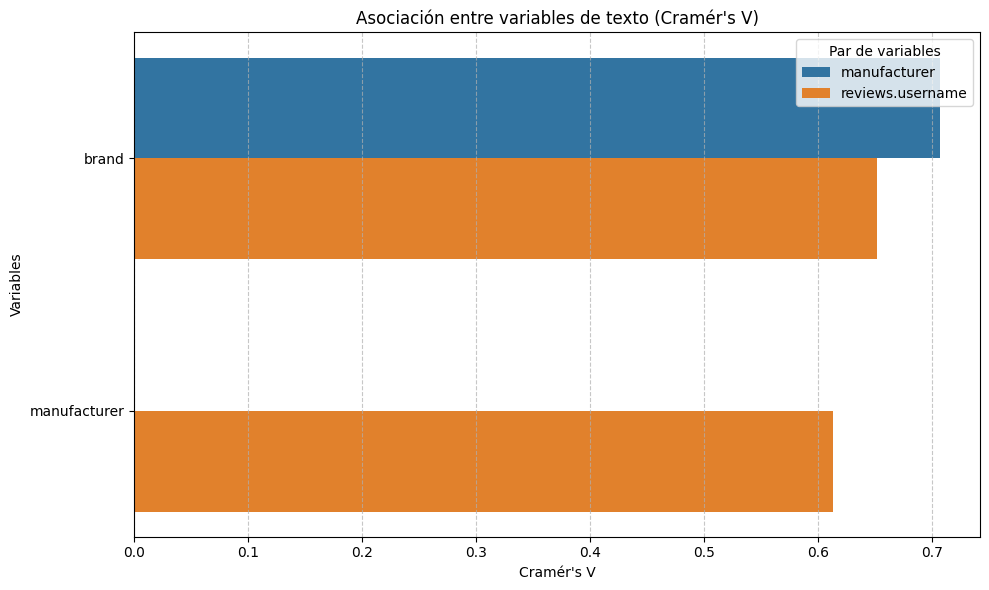

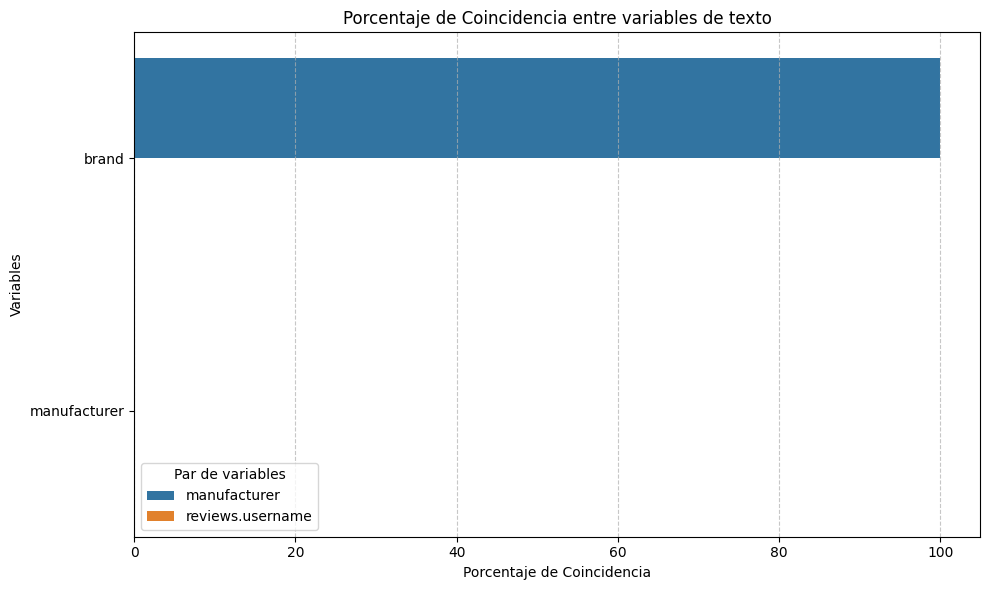

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import itertools

# --- Code to define summary_df ---
text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")

def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada (not strictly needed for summary_df, but part of original logic)
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)
# --- End of code to define summary_df ---

# =========================
# 6.1. Visualización de Cramér's V
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="Cramér's V", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("Cramér's V", ascending=False))
plt.title("Asociación entre variables de texto (Cramér's V)")
plt.xlabel("Cramér's V")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================
# 6.2. Visualización de % coincidencia
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="% coincidencia", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("% coincidencia", ascending=False))
plt.title("Porcentaje de Coincidencia entre variables de texto")
plt.xlabel("Porcentaje de Coincidencia")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Conclusion final

El dataset original es adecuado para analizar patrones de reseñas negativas y construir indicadores de riesgo asociados al desempeño de productos. Contiene texto, ratings, fechas, productos y categorías, lo cual permite generar variables útiles para evaluar la percepción del consumidor.
Sin embargo, el dataset tiene una limitación fundamental: no incluye datos reales de ventas. Por lo tanto, el proyecto no podrá predecir una caída de ventas en sentido estricto, sino un riesgo de caída de ventas basado en señales indirectas de insatisfacción del cliente.
Los principales problemas identificados son el desbalance de clases, la alta concentración de reseñas positivas, la presencia de variables con muchos nulos, la alta cardinalidad en variables de producto y usuario, variables potencialmente redundantes y escalas inconsistentes entre variables numéricas.
A pesar de estas limitaciones, el dataset es utilizable si se redefine correctamente el problema como una predicción de riesgo. Para ello, será necesario construir variables agregadas por producto y periodo, identificar reseñas negativas, analizar cambios en el rating promedio y usar modelos capaces de detectar patrones asociados a deterioro en la percepción del producto.


#**Ingeniería de características estándar**

A continuación presentaré 3 propuestas en Python, dependientes entre sí para crear features estándar usando su dataset de reseñas de Amazon, adaptado al nuevo enfoque: predecir riesgo de caída de ventas de un producto con base en reseñas negativas.


Limpieza inicial

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Cargar dataset original
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DATASET ORIGINAL")
print("Shape:", df.shape)
display(df.head())

# =========================
# 2. Limpieza inicial
# =========================

# Convertir fechas
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")

# Convertir numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(
    df["reviews.numHelpful"],
    errors="coerce"
).fillna(0)

# Eliminar columnas con demasiados nulos, si existen
columnas_eliminar = ["reviews.didPurchase", "reviews.id"]

df = df.drop(
    columns=[col for col in columnas_eliminar if col in df.columns],
    errors="ignore"
)

# =========================
# 3. Features básicas por reseña
# =========================

# Texto combinado
df["review_full_text"] = (
    df["reviews.title"].astype(str) + " " + df["reviews.text"].astype(str)
)

# Longitud del texto
df["review_length_chars"] = df["review_full_text"].apply(len)
df["review_length_words"] = df["review_full_text"].apply(lambda x: len(x.split()))

# Separar reviews.date en año y mes
df["review_year"] = df["reviews.date"].dt.year.fillna(0).astype(int)
df["review_month"] = df["reviews.date"].dt.month.fillna(0).astype(int)

# Eliminar la columna original de fecha después de separarla
df = df.drop(columns=["reviews.date"], errors="ignore")

# Variables binarias de satisfacción
df["is_negative_review"] = np.where(df["reviews.rating"] <= 2, 1, 0)
df["is_neutral_review"] = np.where(df["reviews.rating"] == 3, 1, 0)
df["is_positive_review"] = np.where(df["reviews.rating"] >= 4, 1, 0)

# Variable de no recomendación
df["not_recommended"] = np.where(df["reviews.doRecommend"] == False, 1, 0)

print("DESPUÉS DE FEATURES POR RESEÑA")
print("Shape:", df.shape)
display(df[[
    "name",
    "reviews.rating",
    "review_year",
    "review_month",
    "review_length_words",
    "is_negative_review",
    "not_recommended"
]].head())

DATASET ORIGINAL
Shape: (28332, 24)


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


DESPUÉS DE FEATURES POR RESEÑA
Shape: (28332, 30)


,name,reviews.rating,review_year,review_month,review_length_words,is_negative_review,not_recommended
0,AmazonBasics AAA Performance Alkaline Batterie...,3,2017,3,51,0,0
1,AmazonBasics AAA Performance Alkaline Batterie...,4,2016,8,24,0,0
2,AmazonBasics AAA Performance Alkaline Batterie...,5,2016,12,23,0,0
3,AmazonBasics AAA Performance Alkaline Batterie...,5,2016,3,25,0,0
4,AmazonBasics AAA Performance Alkaline Batterie...,5,2017,4,20,0,0


#Propuesta 1. Features agregadas por producto y periodo

In [ ]:
product_features = df.groupby(["name", "review_year", "review_month"]).agg(
    monthly_reviews=("reviews.rating", "count"),
    monthly_avg_rating=("reviews.rating", "mean"),
    min_rating=("reviews.rating", "min"),
    max_rating=("reviews.rating", "max"),
    negative_reviews=("is_negative_review", "sum"),
    neutral_reviews=("is_neutral_review", "sum"),
    positive_reviews=("is_positive_review", "sum"),
    not_recommended_count=("not_recommended", "sum"),
    avg_helpful_votes=("reviews.numHelpful", "mean"),
    total_helpful_votes=("reviews.numHelpful", "sum"),
    avg_review_length_words=("review_length_words", "mean")
).reset_index()

# Redondear avg_rating a 2 decimales
product_features['avg_rating'] = product_features['avg_rating'].round(2)

# =========================
# Añadir Brand y Primary Categories a product_features
# =========================
# Estas columnas son atributos a nivel de producto.
product_brand_category = df[['name', 'brand', 'primaryCategories']].drop_duplicates(subset=['name'])

# Fusionar con product_features
product_features = product_features.merge(
    product_brand_category,
    on='name',
    how='left'
)

# Ratios por producto
product_features["negative_review_rate"] = (
    product_features["negative_reviews"] / product_features["total_reviews"]
)

product_features["positive_review_rate"] = (
    product_features["positive_reviews"] / product_features["total_reviews"]
)

product_features["not_recommended_rate"] = (
    product_features["not_recommended_count"] / product_features["total_reviews"]
)

# Antigüedad en días (Estas columnas ya no se pueden calcular porque se eliminó 'reviews.date')
# product_features["review_period_days"] = (
#     product_features["last_review_date"] - product_features["first_review_date"]
# ).dt.days

# Frecuencia de reseñas (Esta columna ya no se puede calcular)
# product_features["review_frequency"] = (
#     product_features["total_reviews"] /
#     product_features["review_period_days"].replace(0, np.nan)
# )

print("FEATURES POR PRODUCTO")
print("Shape:", product_features.shape)
display(product_features.head())

FEATURES POR PRODUCTO
Shape: (561, 19)


,name,review_year,review_month,total_reviews,avg_rating,min_rating,max_rating,negative_reviews,neutral_reviews,positive_reviews,not_recommended_count,avg_helpful_votes,total_helpful_votes,avg_review_length_words,brand,primaryCategories,negative_review_rate,positive_review_rate,not_recommended_rate
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017,6,1,5.00,5,5,0,0,1,0,44.000000,44.0,102.000000,Amazon,Electronics,0.0,1.000000,0.000000
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017,7,5,4.60,4,5,0,0,5,0,0.200000,1.0,45.400000,Amazon,Electronics,0.0,1.000000,0.000000
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017,8,9,4.22,3,5,0,1,8,1,0.222222,2.0,28.555556,Amazon,Electronics,0.0,0.888889,0.111111
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017,9,3,4.67,4,5,0,0,3,0,0.000000,0.0,21.666667,Amazon,Electronics,0.0,1.000000,0.000000
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017,10,1,5.00,5,5,0,0,1,0,0.000000,0.0,25.000000,Amazon,Electronics,0.0,1.000000,0.000000


#Propuesta 2: Features temporales producto-mes